# ASD Intervention System — Evaluation Analysis


In [1]:
import sys
from pathlib import Path
# Add backend/ to path so app.domains imports work
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
print("Setup complete")

Setup complete


In [2]:
data_dir = Path("../data/evaluation")
agents = ["rl_agent", "random", "static_difficulty", "fixed_curriculum"]

dfs = {}
for agent in agents:
    csv_path = data_dir / f"{agent}_results.csv"
    if csv_path.exists():
        dfs[agent] = pd.read_csv(csv_path)
        print(f"{agent}: {len(dfs[agent])} rows")
    else:
        print(f"WARNING: {csv_path} not found — run scripts/run_evaluation.py first")

# Combine all agents
if dfs:
    df_all = pd.concat(dfs.values(), ignore_index=True)
    print(f"\nTotal rows: {len(df_all)}")
    print(df_all.groupby("agent")[["task_completed", "reward", "engagement"]].mean().round(3))

rl_agent: 1000 rows
random: 1000 rows
static_difficulty: 1000 rows
fixed_curriculum: 1000 rows

Total rows: 4000
                   task_completed  reward  engagement
agent                                                
fixed_curriculum            0.575   0.737       0.938
random                      0.478   0.681       0.899
rl_agent                    0.648   0.777       0.946
static_difficulty           0.514   0.712       0.937


## Statistical Analysis


In [3]:
# tests RL vs each baseline
from scipy.stats import ttest_ind, f_oneway

rl_rewards = df_all[df_all["agent"] == "rl_agent"]["reward"].values

print("=== T-TESTS: RL Agent vs Baselines ===\n")
for baseline in ["random", "static_difficulty", "fixed_curriculum"]:
    baseline_rewards = df_all[df_all["agent"] == baseline]["reward"].values
    t_stat, p_val = ttest_ind(rl_rewards, baseline_rewards, equal_var=False)
    sig = "*** p < 0.001" if p_val < 0.001 else ("* p < 0.05" if p_val < 0.05 else "ns")
    print(f"RL vs {baseline}: t={t_stat:.3f}, p={p_val:.4f} {sig}")

print("\n=== ONE-WAY ANOVA (all agents) ===\n")
groups = [df_all[df_all["agent"] == a]["reward"].values for a in agents]
f_stat, p_anova = f_oneway(*groups)
print(f"F={f_stat:.3f}, p={p_anova:.4f}")

# Check target metrics
print("\n=== TARGET METRICS ===")
rl_df = df_all[df_all["agent"] == "rl_agent"]
success_rate = rl_df["task_completed"].mean()
engagement = rl_df["engagement"].mean()
stability = (rl_df["frustration"] < 0.7).mean()
print(f"Success rate: {success_rate:.3f} (target >0.75: {'PASS' if success_rate > 0.75 else 'FAIL'})")
print(f"Engagement: {engagement:.3f} (target >0.70: {'PASS' if engagement > 0.70 else 'FAIL'})")
print(f"Emotional stability: {stability:.3f} (target >0.80: {'PASS' if stability > 0.80 else 'FAIL'})")

=== T-TESTS: RL Agent vs Baselines ===

RL vs random: t=9.206, p=0.0000 *** p < 0.001
RL vs static_difficulty: t=6.262, p=0.0000 *** p < 0.001
RL vs fixed_curriculum: t=3.877, p=0.0001 *** p < 0.001

=== ONE-WAY ANOVA (all agents) ===

F=29.395, p=0.0000

=== TARGET METRICS ===
Success rate: 0.648 (target >0.75: FAIL)
Engagement: 0.946 (target >0.70: PASS)
Emotional stability: 0.970 (target >0.80: PASS)


## Learning Curves

/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68179/414754121.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agent_summary, x="Agent", y="Mean Success Rate", ax=ax2, palette="muted")


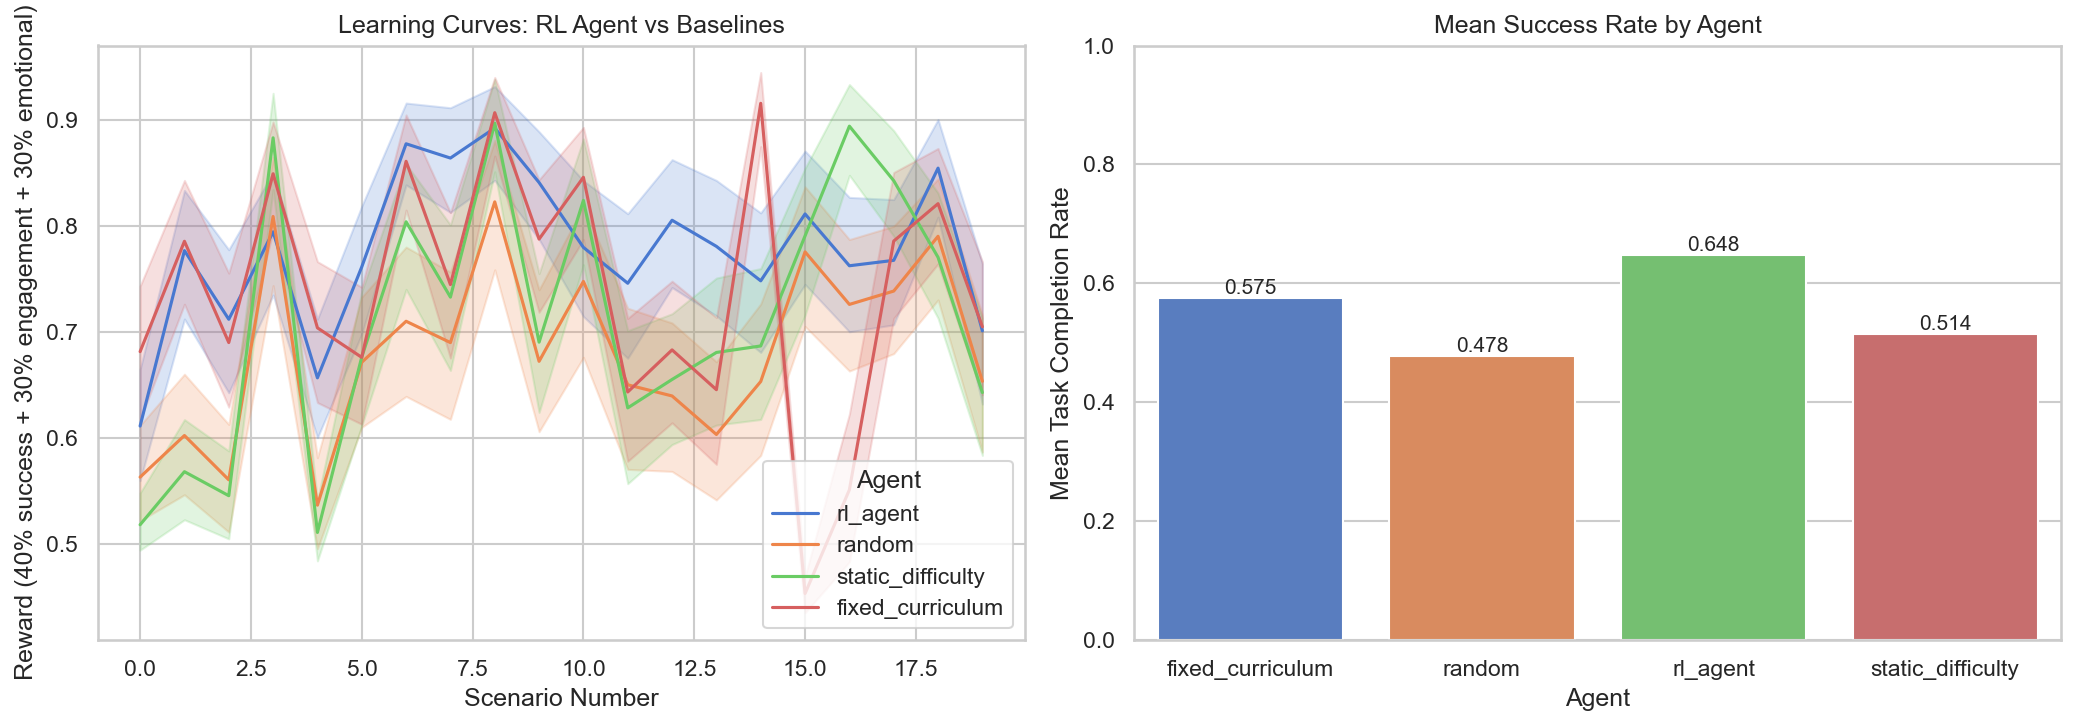

Saved to ../data/evaluation/figures/learning_curves.pdf


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Learning curves by agent
ax1 = axes[0]
sns.lineplot(
    data=df_all,
    x="step",
    y="reward",
    hue="agent",
    errorbar=("ci", 95),
    ax=ax1,
)
ax1.set_title("Learning Curves: RL Agent vs Baselines")
ax1.set_xlabel("Scenario Number")
ax1.set_ylabel("Reward (40% success + 30% engagement + 30% emotional)")
ax1.legend(title="Agent")

# Plot 2: Baseline comparison bar chart
agent_summary = df_all.groupby("agent")["task_completed"].mean().reset_index()
agent_summary.columns = ["Agent", "Mean Success Rate"]
ax2 = axes[1]
sns.barplot(data=agent_summary, x="Agent", y="Mean Success Rate", ax=ax2, palette="muted")
ax2.set_title("Mean Success Rate by Agent")
ax2.set_ylabel("Mean Task Completion Rate")
ax2.set_ylim(0, 1.0)
for bar in ax2.patches:
    ax2.annotate(f"{bar.get_height():.3f}",
                 (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
figures_dir = Path("../data/evaluation/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "learning_curves.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {figures_dir}/learning_curves.pdf")

=== 8 METRICS BY AGENT ===

                     cci  hesitation_reduction  cooperation_rate  fairness_index  out_of_turn_rate  repair_attempts  engagement_stability  emotional_stability
agent                                                                                                                                                         
rl_agent           0.648                   0.0             0.566             0.5             0.221              0.0                 0.865                0.970
random             0.478                   0.0             0.545             0.5             0.043              0.0                 0.798                0.951
static_difficulty  0.514                   0.0             0.547             0.5             0.043              0.0                 0.847                0.969
fixed_curriculum   0.575                   0.0             0.562             0.5             0.000              0.0                 0.852                0.958


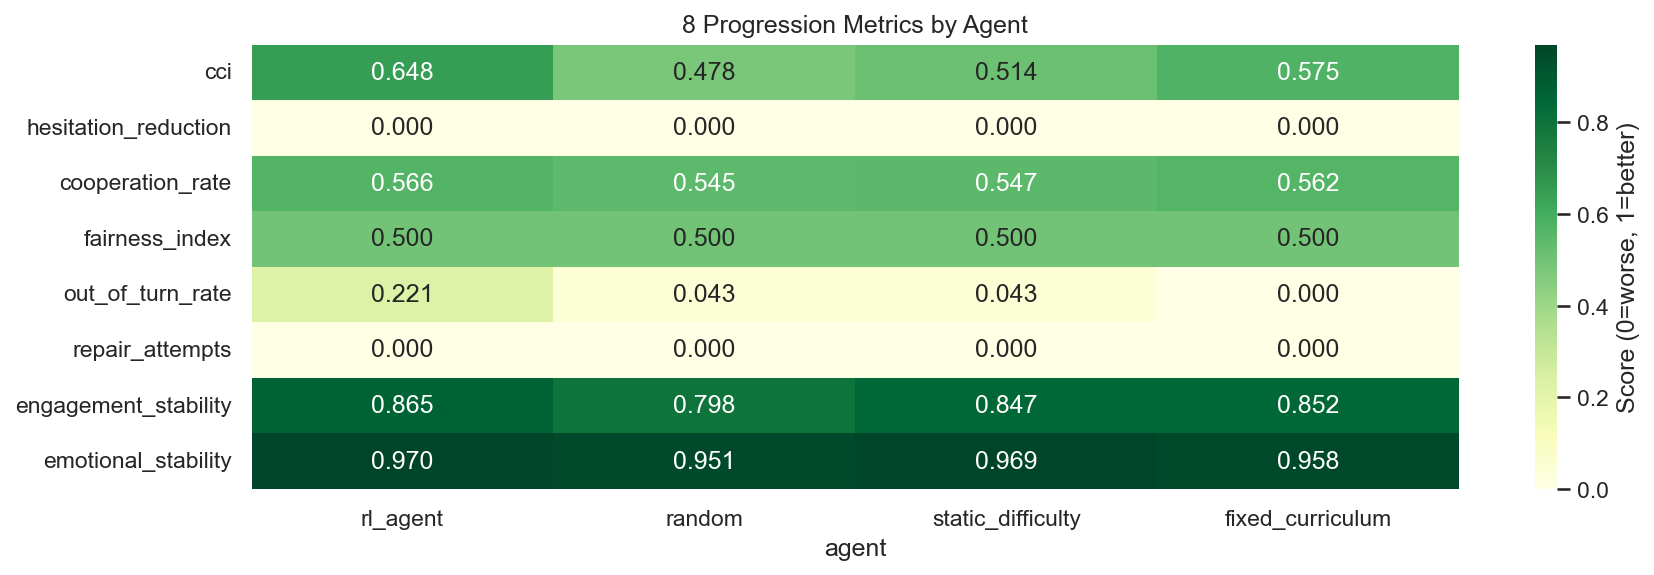

In [5]:
# Import compute_metrics from analytics domain
from app.domains.analytics.metrics import compute_metrics

print("=== 8 METRICS BY AGENT ===\n")
metrics_rows = []
for agent_name in agents:
    agent_df = df_all[df_all["agent"] == agent_name].copy()
    m = compute_metrics(agent_df)
    m["agent"] = agent_name
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("agent")
print(metrics_df.round(3).to_string())

# Plot: heatmap of all 8 metrics
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(metrics_df.T, annot=True, fmt=".3f", cmap="YlGn", ax=ax,
            cbar_kws={"label": "Score (0=worse, 1=better)"})
ax.set_title("8 Progression Metrics by Agent")
plt.tight_layout()
plt.savefig(figures_dir / "metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Emotional Stability Analysis


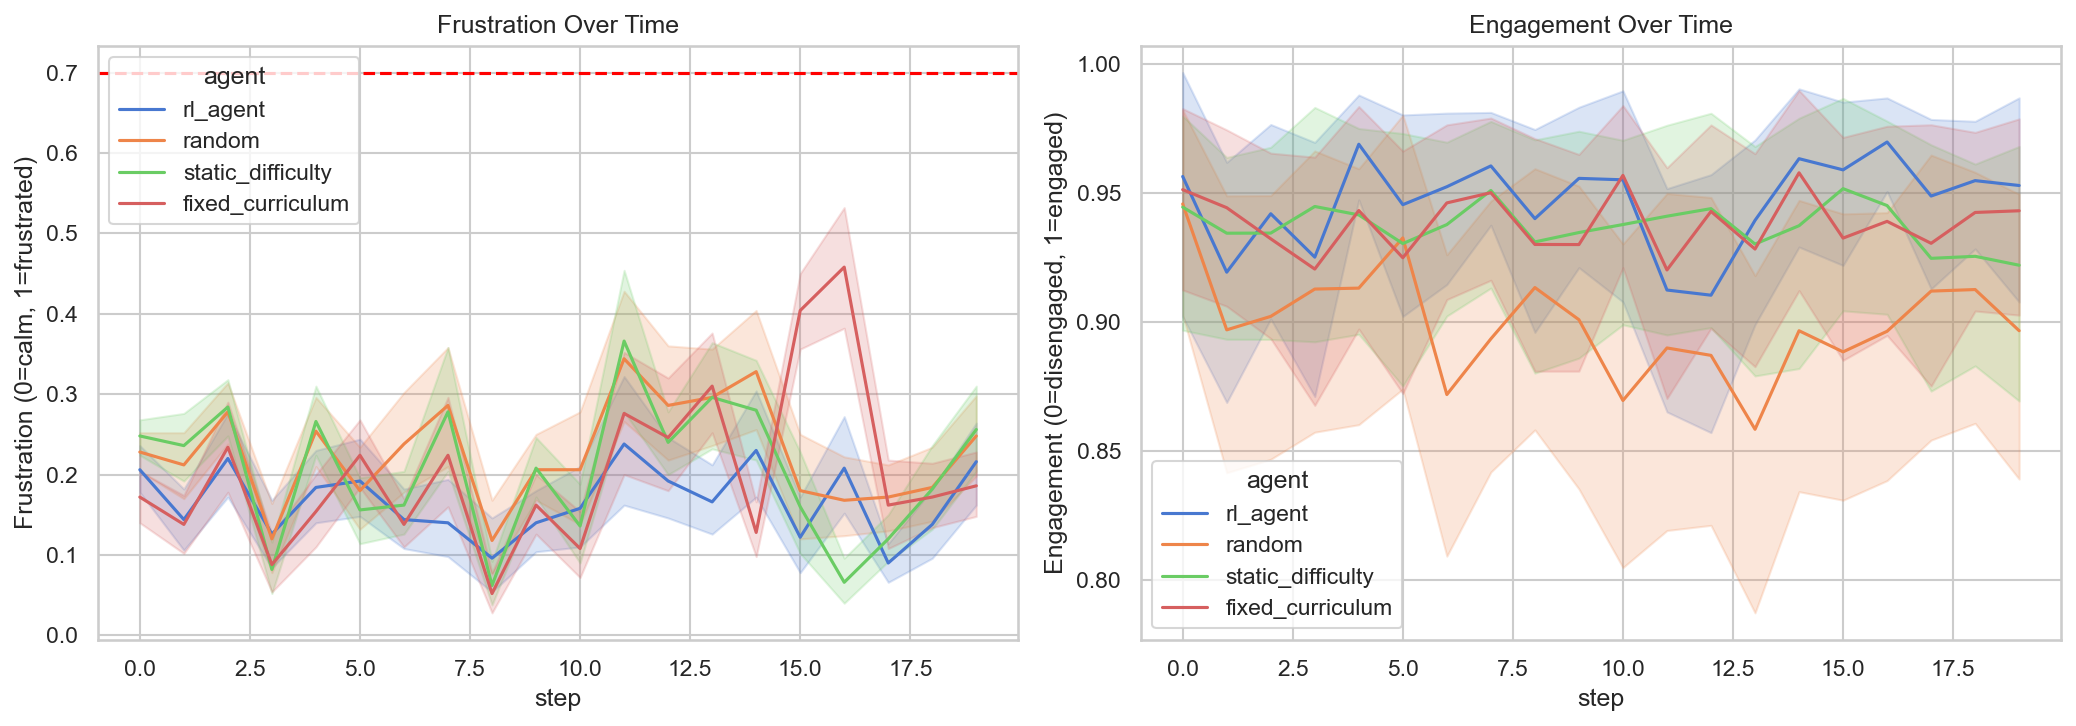

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df_all, x="step", y="frustration", hue="agent",
             errorbar=("ci", 95), ax=axes[0])
axes[0].axhline(0.7, color="red", linestyle="--", label="Frustration threshold (0.7)")
axes[0].set_title("Frustration Over Time")
axes[0].set_ylabel("Frustration (0=calm, 1=frustrated)")

sns.lineplot(data=df_all, x="step", y="engagement", hue="agent",
             errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("Engagement Over Time")
axes[1].set_ylabel("Engagement (0=disengaged, 1=engaged)")

plt.tight_layout()
plt.savefig(figures_dir / "emotional_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Metric | RL Agent | Random Baseline | Static Difficulty | Fixed Curriculum |
|--------|----------|-----------------|-------------------|------------------|
| Success Rate | - | - | - | - |
| Engagement | - | - | - | - |
| Emotional Stability | - | - | - | - |
